# Parallax Airplane Detection Pipeline
### End-to-End Demonstration

This notebook demonstrates the full execution of the parallax aircraft detection pipeline, reimplementing the method proposed by Liu et al. (2020) for detecting flying aircraft in Sentinel-2 multispectral imagery using inter-band parallax effects. The notebook provides a walk-through of all pipeline stages with supporting visualisation. Users can change inputs to test he pipeline functionality. 

The pipeline proceeds in five stages:

0. **Preparation**:
Google Earth Engine Authentication and selection area and date range of interest. 

1. **Candidate Screening** *(Google Earth Engine)*: 
Band 3 reflectance anomaly detection across all Sentinel-2 tiles in the selected area and date range, exported as binary masks

2. **Candidate Filtering** *(Local)* 
Sequential refinement of candidates through morphological transformation, cluster exclusion, road exclusion, and seam-line exclusion

3. **Chip Download** *(Google Earth Engine)* 
Image chip extraction around surviving candidates

4. **Aircraft Confirmation** *(Local)* 
Verification of true aircraft via proportional inter-band displacement

4. **ADS-B Cross-Reference** *(OpenSky Network)* 
Cross-reference of detections with ADS-B records at satellite overpass time

In [125]:
#imports and global settings
import sys
sys.path.append('../src')

import ee

from pipeline.pipeline import Pipeline
from pipeline.utils import gee_auth, io
from pipeline.s1_gee_candidates import aoi_selection, candidate_screening
from pipeline.s2_filter import transform, cluster_filter, road_filter, seamline_filter
from pipeline.s3_download import chip_download
from pipeline.s4_confirmation import reflectance_check, collinearity_check, displacement_check, visualise_confirmation
from pipeline.s5_evaluation import evaluate, export

# Step 0: Preparation

## GEE Authentication

- First time use: Run `earthengine authenticate` in terminal
- A valid GEE project ID must be saved to `.env` as `GEE_PROJECT` prior to running any GEE-dependent steps.
- Then run next block to initialise GEE. 
- This opens a browser window prompting sign-in with a Google account authorised for Google Earth Engine. 
- Credentials are loaded automatically on all subsequent runs.
- Users without a GEE account should move to `02_demo.ipynb` to run pipeline with pre-downloaded data.

In [18]:
gee_auth.gee_auth_init()

GEE initialised successfully


## Map Area Selection

**Parameters:** 
- `aoi`: User defines area of interest by drawing a rectangle on the map below or by passing Sentinel-2 tile ID to the pipeline
- `start_date`: Start of query window
- `start_date`: End of query window

**Demonstration:**
- For this demonstration, a Sentinel-2 tile ID will be passed directly to the pipeline.


### Option 1: Define AOI on Map

In [ ]:
# load interactive map 
aoi_polygon = aoi_selection.GEE_map()
aoi_polygon

In [ ]:
aoi = aoi_selection.get_aoi(aoi_polygon)
aoi_selection.aoi_summary(aoi)

### Option 2: Define AOI via Sentinel-2 Image Tile

Tile codes can be identified via the [Sentinel-2 Grid explorer](https://dpird-dma.github.io/Sentinel-2-grid-explorer/)

In [3]:
start_date = '2019-10-01' #Format: 'YYYY-MM-DD'
end_date = '2019-10-31' 
tile_name = '31UEU'

In [4]:
#define AOI via GEE call
image = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', f'{tile_name}'))
    .first())

# Get tile geometry
aoi = image.geometry()
aoi_selection.aoi_summary(aoi)
aoi = aoi

AOI CRS  : EPSG:4326
West     : 2.9996
East     : 4.6450
South    : 52.2515
North    : 53.2497


## Start a Pipeline Run

- Every stage from here on is scoped to a `run_id`, so re-running the notebook (or running it twice for two different AOIs) does not mix outputs together. 
- Each run gets its own database rows and its own `data/runs/run_<id>/` directory on disk.
- `pipeline.start_run()` creates the `pipeline_run` row and returns its id. 
- Each of the subsequent steps are called directly (e.g. `transform.run_transformation(run_id)`) 
- Intermediate results from past runs are inspectable by setting the `run_id` (e.g. `run_id = 2`)

In [5]:
pipeline = Pipeline()
run_id = pipeline.start_run(aoi, start_date, end_date, tile_name=tile_name)
print(f"run_id = {run_id}")

run_id = 1


## Step 1: Candidate Screening

Sentinel-2 images are loaded from GEE for the selected area and date range. 
For each image tile, a binary candidate mask is generated and exported as a GeoTIFF to `data/runs/run_id/step1_masks/`.
Large tiles exceeding the GEE download limit are automatically split into quadrants and merged after download.

**Input:**
- `aoi`: Area of interest
- `start_date` / `end_date`: Query window

**Output:**
- Binary GeoTIFF masks per image tile in format `data/runs/run_id/step1_masks/YYYYMMDD_TILE_candidates.tif`
- `1` = candidate pixel, `0` = background
- Mask metadata stored `mask` table

**Demonstration:**
- The Sentinel-2 tile `31UEU` is queried for the range 01/10/2019-31/10/2019
- `inspect_candidate_mask()` can be used to visualise individual exported masks


In [6]:
candidate_screening.param_summary(aoi, start_date, end_date)

Pipeline Configuration
    West:   2.9996
    East:   4.6450
    South:  52.2515
    North:  53.2497
Date range
    Start:  2019-10-01
    End:    2019-10-31


In [ ]:
candidate_screening.run_candidate_screening(run_id, aoi, start_date, end_date, tile_name)

#### Visual Inspection of Binary Mask

Candidate Screening Inspection
File:               20191028_T31UEU_candidates.tif
Shape:              (10981, 10981)
Unique values:      [0 1]
Candidate pixels:   71
Total pixels:       120582361
Candidate fraction: 0.0001%


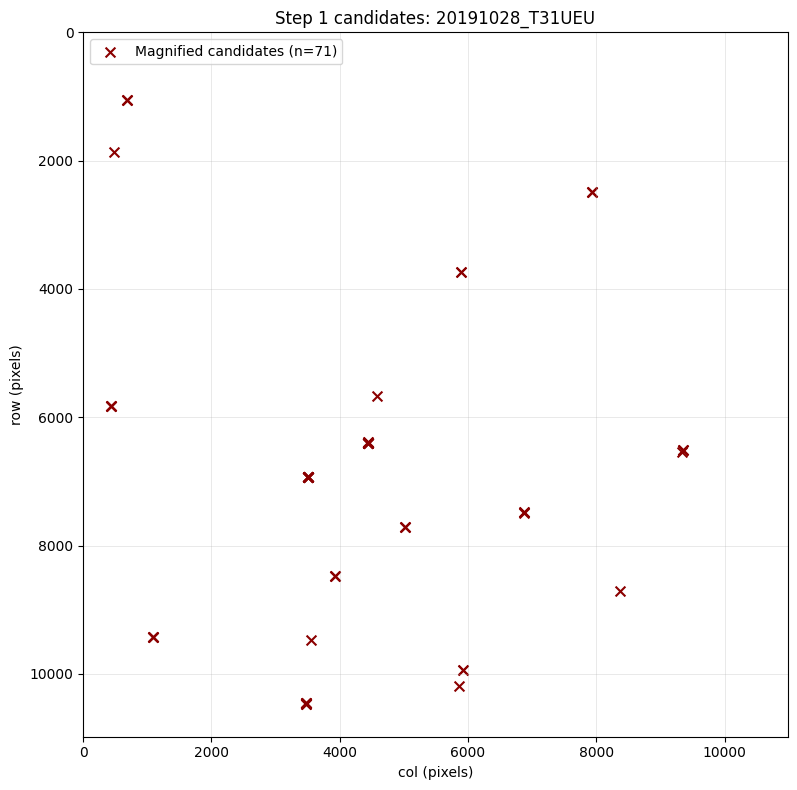

In [8]:
#Define date + tile for inspection of individual mask

date = '20191028' #format: '20190410'
tile = 'T31UEU' #format: 'T50TMK'

candidate_screening.inspect_candidate_mask(run_id, date, tile)

## Step 2: Candidate Refinement

The binary masks from Step 1 are processed through four sequential filtering stages to remove false positives and isolate aircraft candidates.

### Step 2a: Transformation

**Input:**
- Binary GeoTIFF masks: `data/runs/run_id/step1_masks/YYYYMMDD_TILE_candidates.tif`

**Processing:**
- Morphological dilation to connect pixels
- Connected component labelling (CCL) to identify and label discrete pixel blobs
- Size filter: blobs exceeding `MAX_OBJECT_SIZE_PX = 100` pixels are removed
- Centroid computation of surviving blobs
- Affine geotransformation of pixel centroids to geographic coordinates (lon/lat, EPSG:4326)

**Output:**
- Candidate centroids inserted into the `candidate` table

**Inspection:**
- `inspect_blobs()`: blob size distribution before and after size filter
- `inspect_transformation()`: step-by-step visualisation of dilation, labelling, and centroid extraction zoomed to the densest candidate region
- `blob_centr_plot()`: geographic distribution of surviving centroids


In [21]:
candidate_centroids = transform.run_transformation(run_id)

20191001_T31UEU: 83 candidate pixels → 33 candidate centroids
20191003_T31UEU: 77 candidate pixels → 29 candidate centroids
20191006_T31UEU: 0 candidates → skipping
20191008_T31UEU: 6597 candidate pixels → 1468 candidate centroids
20191011_T31UEU: 748 candidate pixels → 45 candidate centroids
20191013_T31UEU: 15374 candidate pixels → 4473 candidate centroids
20191016_T31UEU: 0 candidates → skipping
20191018_T31UEU: 166 candidate pixels → 75 candidate centroids
20191021_T31UEU: 0 candidates → skipping
20191023_T31UEU: 456 candidate pixels → 49 candidate centroids
20191026_T31UEU: 4226 candidate pixels → 943 candidate centroids
20191028_T31UEU: 71 candidate pixels → 20 candidate centroids
Inserted into candidate table (run_id=1)

Total candidates across all images: 7135 candidate centroids


#### Visual Inspection of Transformation Step

In [22]:
#Define date + tile to inspect inspect individual binary mask
date = '20191008' #format: '20190410'
tile = 'T31UEU' #format: 'T50TMK'

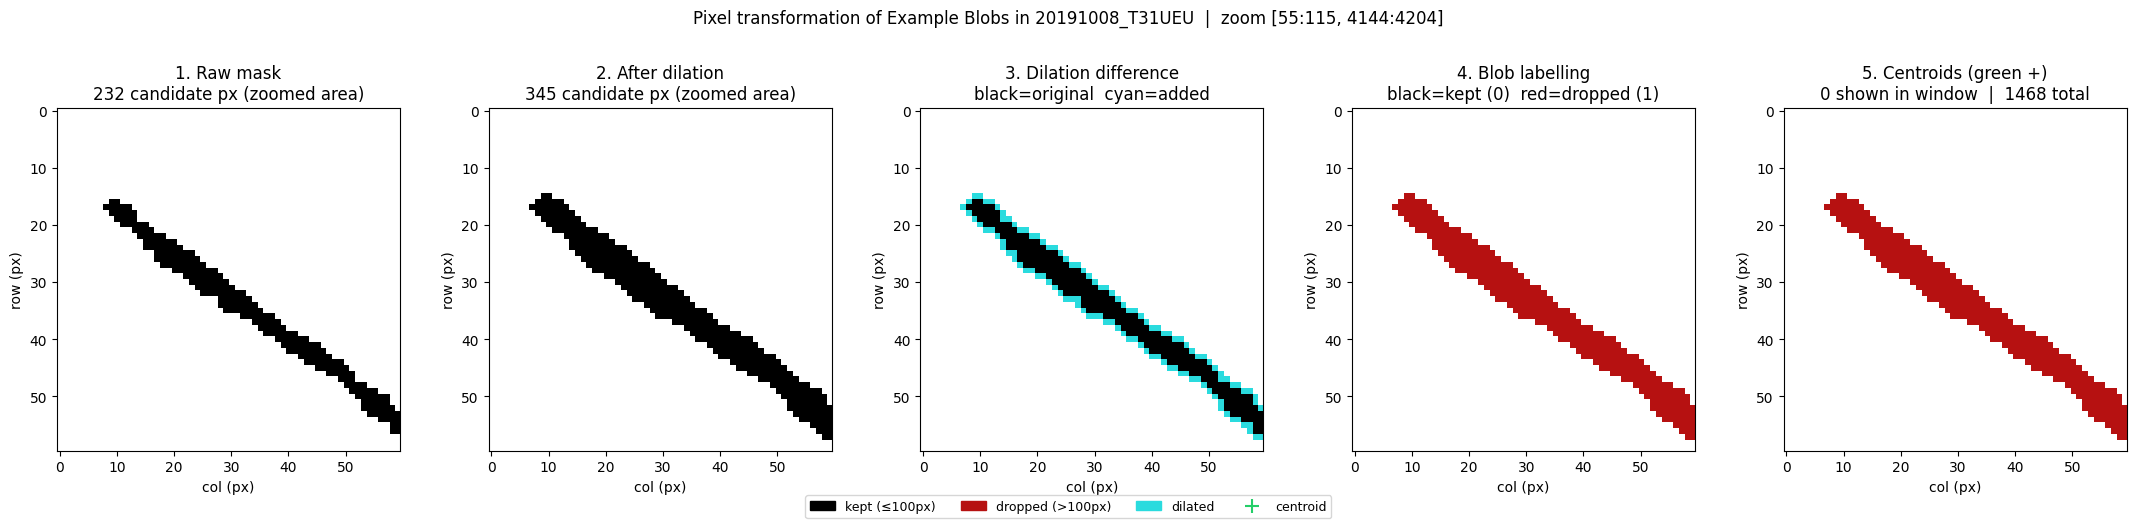

In [23]:
#Inspection of pixel transformation (zoomed)
zoom = 30
transform.inspect_transformation(run_id, date, tile, zoom)

Transformation Inspection
File                         : 20191008_T31UEU_candidates.tif
Candidate px before dilation : 6597
Candidate px after dilation  : 18548
Pixels added by dilation     : 11951
Total blobs found            : 1474
Kept (≤100px)                : 1468
Dropped (>100px)             : 6
Largest dropped              : 418 px
Largest kept                 : 69 px
Smallest kept                : 4 px


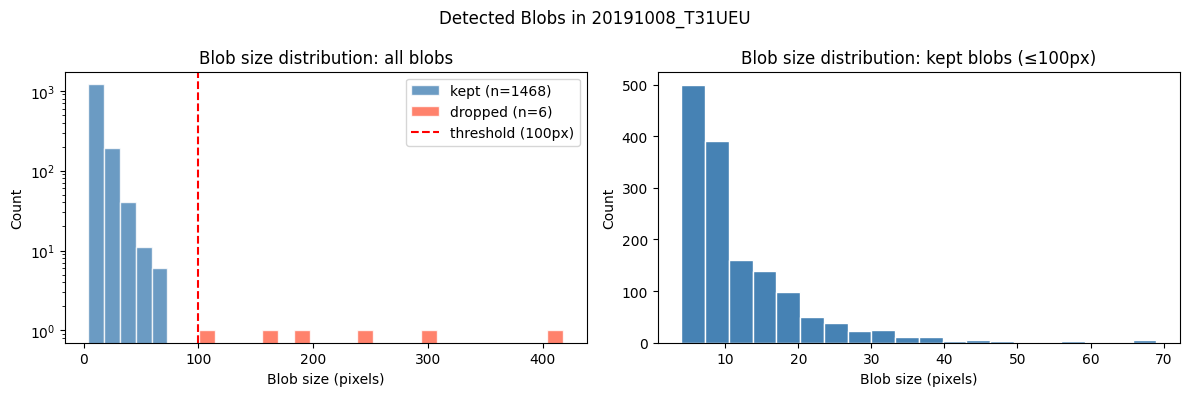

In [24]:
#Inspection of blob size distribution in selected mask
transform.inspect_blobs(run_id, date, tile)

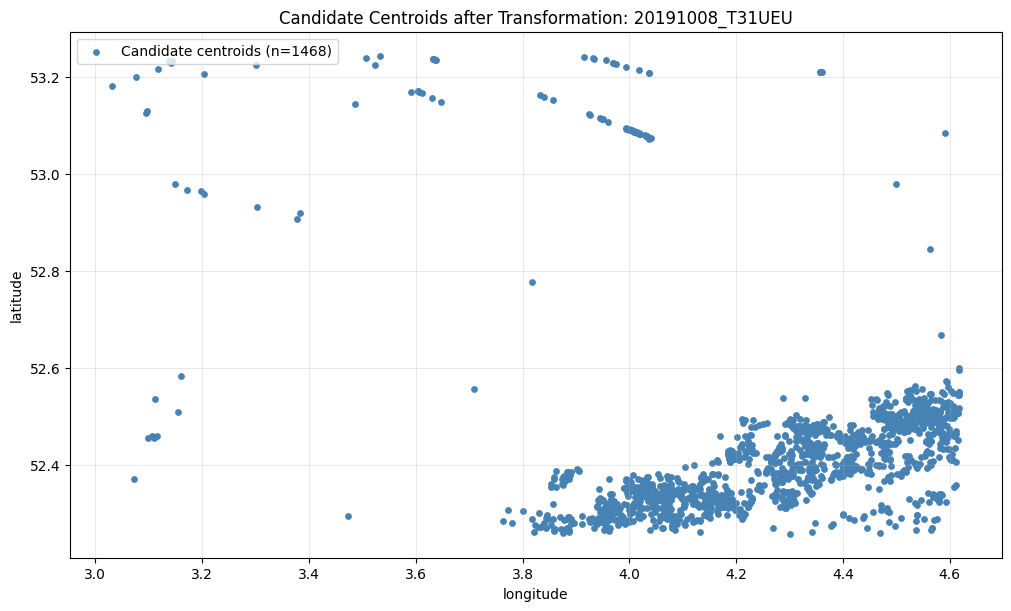

In [25]:
#Inspection of spatial distribution of selected mask
transform.blob_centr_plot(run_id, date, tile)

### Step 2b: Cluster Exclusion

**Input:**
- Candidates from the `candidate` table

**Processing:**
- Pairwise Haversine distance matrix computed per scene
- Candidates with 3 or more neighbours within a 1500 m buffer are excluded, along with all their neighbours

**Output:**
- `cluster_excluded` flag set on excluded rows in the candidate table

**Inspection:**
- `cluster_filtered_plot()`: geographic distribution of excluded and surviving candidates with 1500 m buffer circles

In [26]:
df_cluster_filtered = cluster_filter.run_cluster_exclusion(run_id, candidate_centroids)

Total candidates before cluster filter: 7135

20191001_T31UEU:
  candidates before : 33
  candidates after  : 17
  excluded          : 16
  min distance      : 32.0 m
  max distance      : 27367.2 m
20191001_T31UEU: 33 → 17

20191003_T31UEU:
  candidates before : 29
  candidates after  : 25
  excluded          : 4
  min distance      : 36.4 m
  max distance      : 44673.6 m
20191003_T31UEU: 29 → 25

20191008_T31UEU:
  candidates before : 1468
  candidates after  : 89
  excluded          : 1379
  min distance      : 31.6 m
  max distance      : 25626.4 m
20191008_T31UEU: 1468 → 89

20191011_T31UEU:
  candidates before : 45
  candidates after  : 3
  excluded          : 42
  min distance      : 31.5 m
  max distance      : 23144.1 m
20191011_T31UEU: 45 → 3

20191013_T31UEU:
  candidates before : 4473
  candidates after  : 166
  excluded          : 4307
  min distance      : 28.2 m
  max distance      : 22222.5 m
20191013_T31UEU: 4473 → 166

20191018_T31UEU:
  candidates before : 75
  cand

#### Visual Inspection of Cluster Filter

Cluster Filter Inspection
Before:     1468 centroids
Survivors:  89 centroids
Removed:    1379 centroids


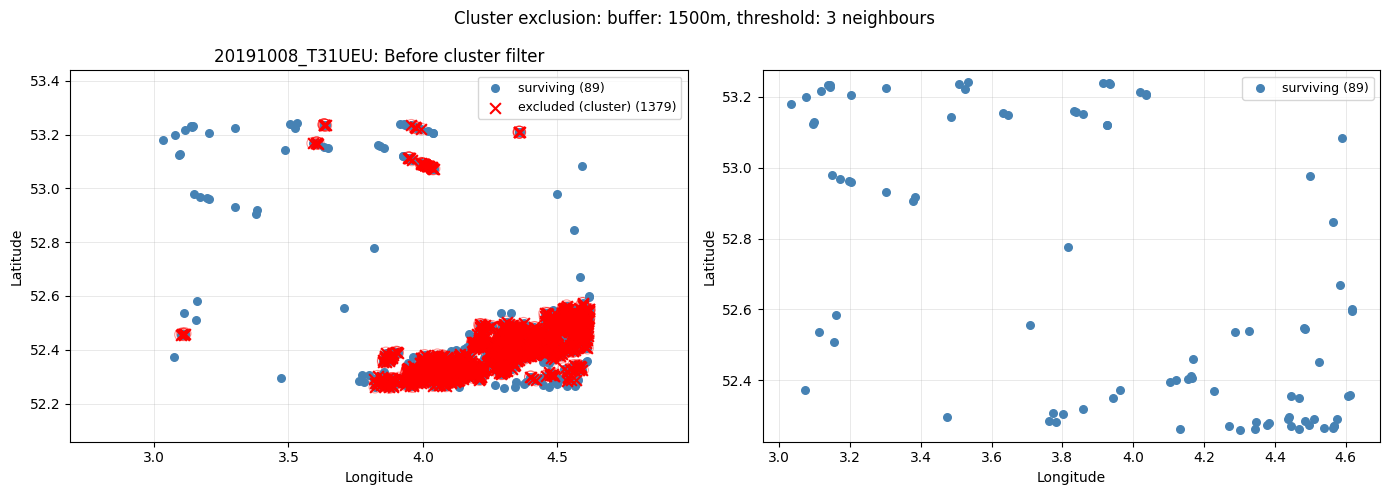

In [27]:
#Exemplary inspection of cluster exclusion in selected mask:
date = '20191008' #format: '20190410'
tile = 'T31UEU' #format: 'T50TMK'

cluster_filter.cluster_filtered_plot(run_id, date, tile)

### Step 2c: Road Exclusion

**Input:**
- Candidates from `candidate` table not excluded by cluster filtering
- Binary masks: `data/runs/run_id/step1_masks/` (needed to determine raster dimensions)

**Processing:**
- A frequency image is built per tile by stacking all candidate centroid positions across all dates
- A linear kernel (half-size 25 px, full size 51×51) is convolved with the frequency image at 18 rotations
- The maximum convolution response across all angles is retained per pixel
- Candidates with a road score exceeding `ROAD_FREQUENCY_THRESHOLD = 5` are excluded

**Output:**
- `road_excluded` flag and `road_score` set on the `candidate´ table
- Frequency image per tile: `data/runs/run_id/step2_road_freq/TILE_frequency.npy`

**Inspection:**
- `kernel_viz()`: visualises the linear kernel at selected rotation angles
- `road_filtered_plot()`: geographic distribution of excluded and surviving candidates. Not shown because 0 road exclusions since scene is over English Channel


In [31]:
df_road_filtered = road_filter.run_road_exclusion(run_id, df_cluster_filtered)

Processing tile T31UEU: 684 candidates across 9 dates
  → frequency image saved: <repo-root>/data/runs/run_1/step2_road_frequency/T31UEU_frequency.npy
  → excluded 0 / 684, kept 684

Updated road_score/road_excluded for 684 candidate(s) in the database


#### Visual Inspection of Road Filter

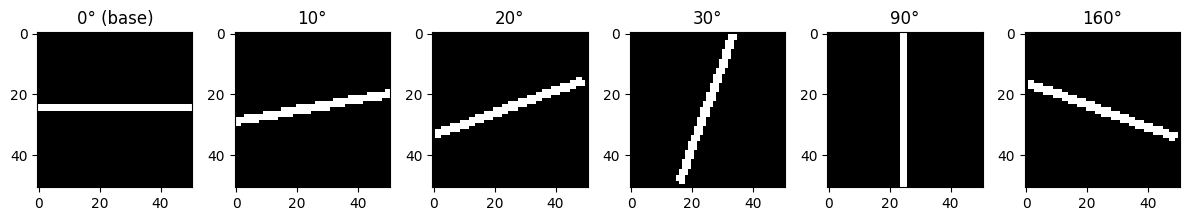

In [32]:
#Inspecting kernel rotations
#Defining angles for inspection 
a_1 = 10
a_2 = 20
a_3 = 70
a_4 = 90
a_5 = 160

road_filter.kernel_viz(a_1, a_2, a_3, a_4, a_5)

Frequency Image Inspection
Frequency image            : T31UEU_frequency.npy
Shape                      : (10981, 10981)
Dates Captured             : 9
Non-zero pixels            : 684
Unique centroid positions  : 684
In freq not in centroids   : 0
In centroids not in freq   : 0
Highlight date 20191028: 20 candidates


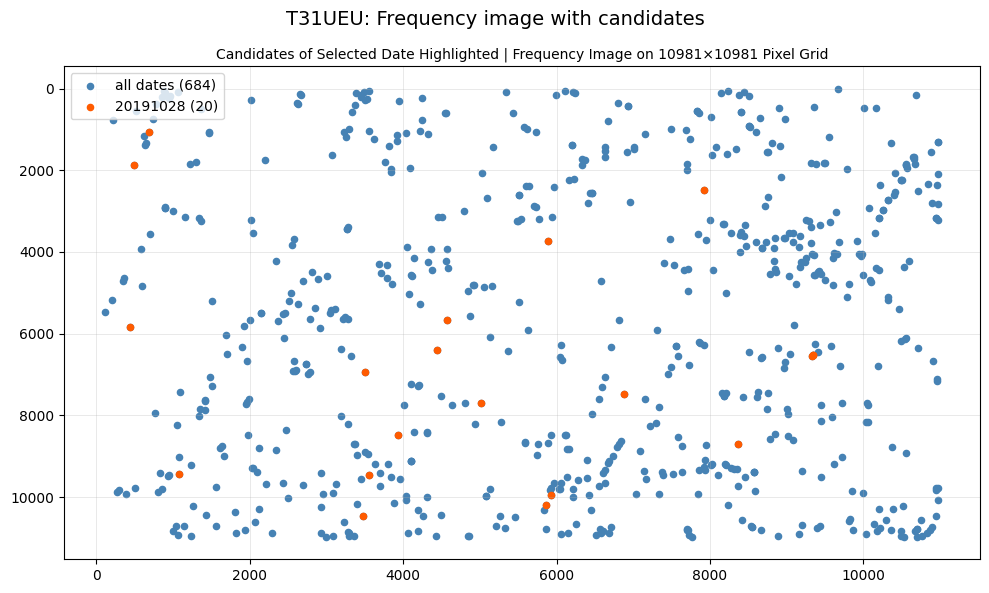

In [33]:
#Define highlight date and tile for inspection of frequency image
highlight_date = '20191028'
tile = 'T31UEU' #format: 'T50TMK'

road_filter.freq_image_plot(run_id, tile, highlight_date)

Road Filter Inspection
Before:     684 centroids
Survivors:  684 centroids
Removed:    0 centroids


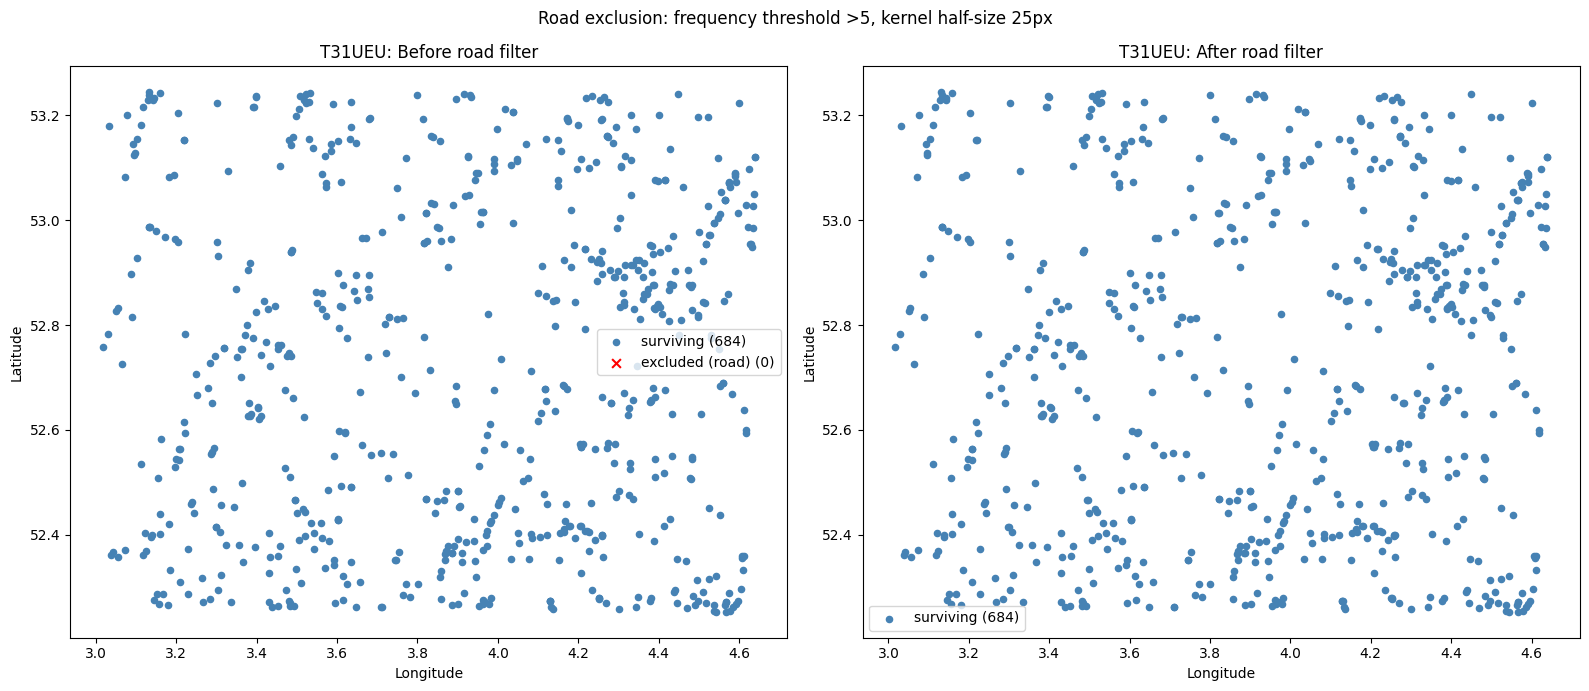

In [34]:
#inspecting road filter on selected frequency image (i.e. tile)
road_filter.road_filtered_plot(run_id, tile)

### Step 2d: Seam-line Exclusion

**Input:**
- Candidates from the `candidate` table not excluded by road filtering

**Processing:**
- MSAC line fitting iterates up to 7 times per scene
- Lines with direction within 68°-82° and minimum 3 inliers within a 50 m buffer are identified as seam-lines
- All inlier candidates are excluded

**Output:**
- `seam_excluded` flag set on excluded rows in the `candidate` table

**Inspection:**
- `plot_seamline_exclusion()`: visualises excluded candidates and the fitted seam-line overlaid on the geographic candidate distribution

In [35]:
df_seam_filtered = seamline_filter.run_seamline_exclusion(run_id, df_road_filtered)


20191001_T31UEU: 17 candidates
iteration 1: best line 72.9°  inliers=5  seam=True
iteration 2: no line found, stopping
5 candidates removed
17 candidates → 12 candidates

20191003_T31UEU: 25 candidates
iteration 1: best line 75.0°  inliers=5  seam=True
iteration 2: best line 74.9°  inliers=5  seam=True
iteration 3: no line found, stopping
10 candidates removed
25 candidates → 15 candidates

20191008_T31UEU: 89 candidates
iteration 1: best line 145.3°  inliers=6  seam=False
not a seam-line direction, stopping
0 candidates removed
89 candidates → 89 candidates

20191011_T31UEU: 3 candidates
iteration 1: no line found, stopping
0 candidates removed
3 candidates → 3 candidates

20191013_T31UEU: 166 candidates
iteration 1: best line 74.9°  inliers=7  seam=True
iteration 2: best line 74.8°  inliers=5  seam=True
iteration 3: best line 89.2°  inliers=5  seam=False
not a seam-line direction, stopping
12 candidates removed
166 candidates → 154 candidates

20191018_T31UEU: 42 candidates
iteratio

#### Visual Inspection of Seam-Line Filter

Plot line angle: 73.0°


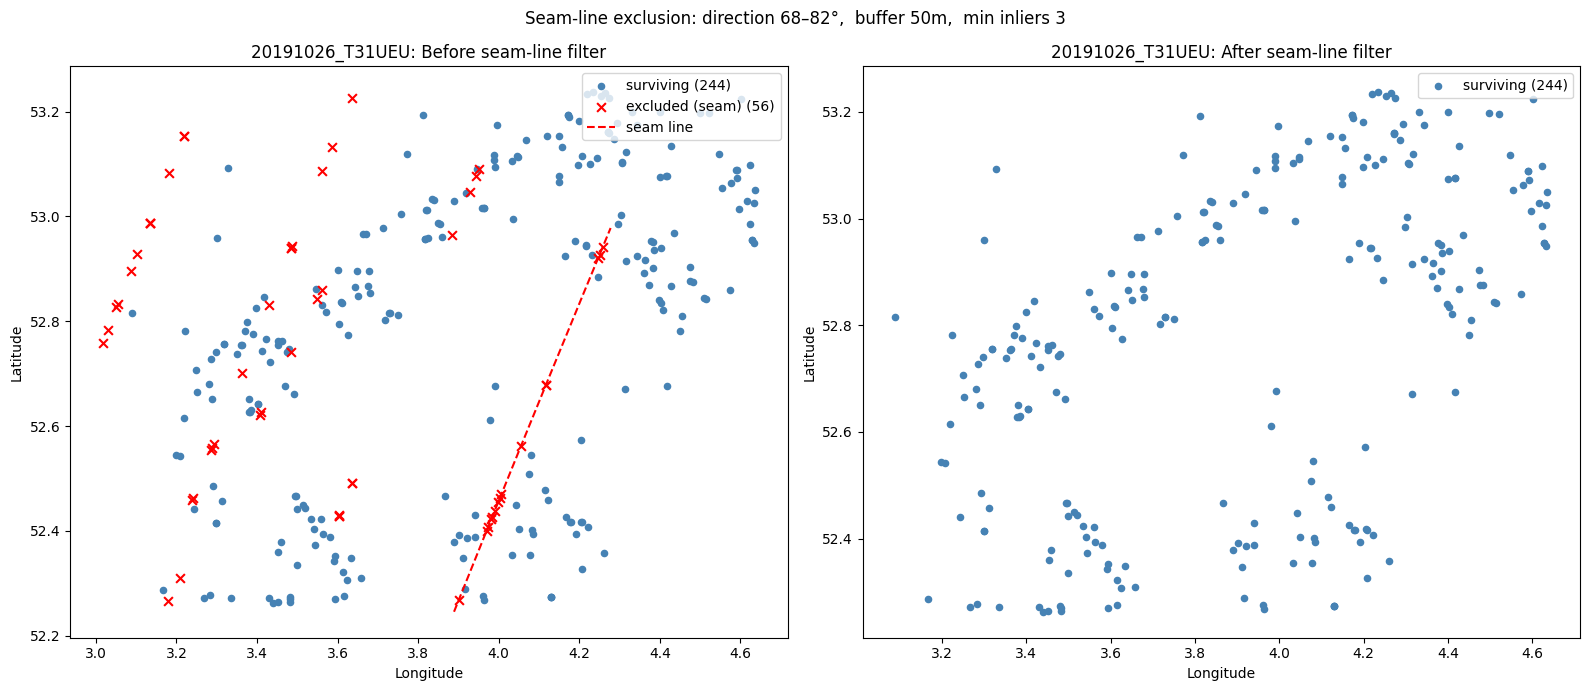

In [43]:
#Inspection of seam line filter on selected mask
date = '20191026' #format: '20190410'
tile = 'T31UEU' #format: 'T50TMK'

seamline_filter.plot_seamline_exclusion(run_id, date, tile)

## Step 3: Image Chip Download

Surviving candidates from Step 2 are used to download 301×301 pixel image chips centred on each candidate centroid from Google Earth Engine. Chips are downloaded in parallel per scene.

**Input:**
- Candidates from `candidate` table that survived all filters.

**Processing:**
- Surviving candidates are loaded across all scenes
- For each scene, the matching Sentinel-2 image is loaded from GEE
- A 301×301 px chip centred on each candidate centroid is downloaded as a GeoTIFF in the tile's native UTM CRS
- Chips are downloaded in parallel per scene using a thread pool

**Output:**
- Image chips per candidate: `data/runs/run_id/chips/YYYYMMDD_TILE_XXXX_chip.tif`
- Three-band GeoTIFF (B2, B3, B4) at 10 m resolution
- Chip metadata stored in `chip` table

**Inspection:**
- `plot_chip()`: displays a single chip as a contrast-stretched RGB composite (R=B4, G=B3, B=B2)
- `plot_chips()`: displays a grid of all chips for a given date and tile
- Note: `idx` must be passed to the inspection functions to preview downloaded chips, which refers to the candidate's real database id (`candidate.id`)

**Demonstration:**
The chips shown in this example run are not available in this repo. Please refer to `02_demo.ipynb` for a pipeline run with pre-downloaded data.

In [48]:
chip_download.run_chip_download(run_id, df_seam_filtered)

Surviving candidates: 584

20191001_T31UEU: 12 candidates
Images found for 20191001 T31UEU: 1
  → downloaded 12, from cache 0, failed 0

20191003_T31UEU: 15 candidates
Images found for 20191003 T31UEU: 1
  → downloaded 15, from cache 0, failed 0

20191008_T31UEU: 89 candidates
Images found for 20191008 T31UEU: 1
  → downloaded 89, from cache 0, failed 0

20191011_T31UEU: 3 candidates
Images found for 20191011 T31UEU: 1
  → downloaded 3, from cache 0, failed 0

20191013_T31UEU: 154 candidates
Images found for 20191013 T31UEU: 1
  → downloaded 154, from cache 0, failed 0

20191018_T31UEU: 32 candidates
Images found for 20191018 T31UEU: 1
  → downloaded 32, from cache 0, failed 0

20191023_T31UEU: 15 candidates
Images found for 20191023 T31UEU: 1
  → downloaded 15, from cache 0, failed 0

20191026_T31UEU: 244 candidates
Images found for 20191026 T31UEU: 1
  → downloaded 244, from cache 0, failed 0

20191028_T31UEU: 20 candidates
Images found for 20191028 T31UEU: 1
  → downloaded 20, from 

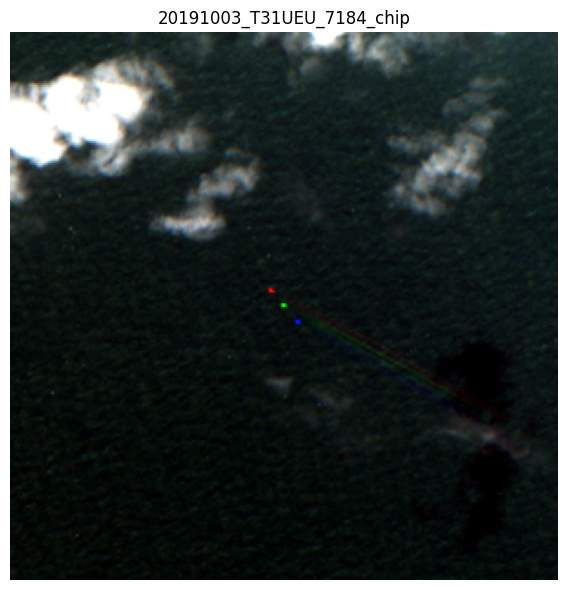

In [55]:
#inspecting single image by candidate id

idx = 7184
visualise_confirmation.plot_chip_by_idx(run_id, idx)

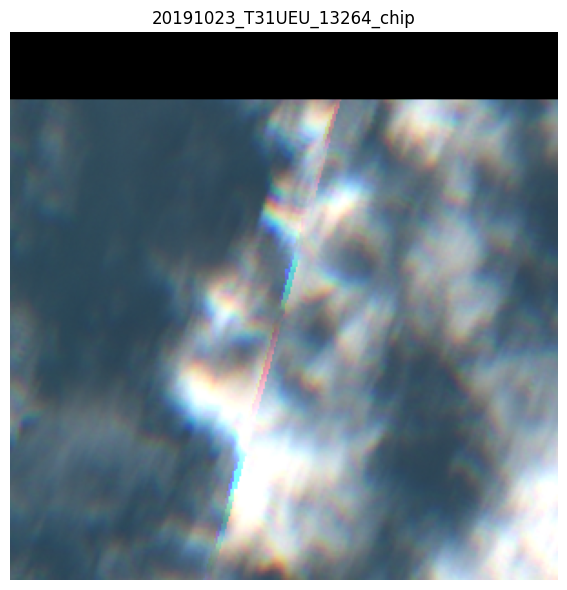

In [57]:
#inspecting single image by candidate id

idx = 13264
visualise_confirmation.plot_chip_by_idx(run_id, idx)

The chips show examples of parallax effects, one resulting from aircraft movement and the other resulting from cloud movement along seamlines. 
Both examples are subject to the subsequent confirmation steps. 

## Step 4: Aircraft Confirmation

Surviving candidates from Step 2 are confirmed as true aircraft detections through a three step connfirmation.

### Step 4a: Inter-band Reflectance Anomaly Segmentation

**Input:**
- Image chips: `data/runs/run_id/chips/YYYYMMDD_TILE_XXXX_chip.tif`
- Candidates from the `candidate` table not excluded by any Step 2 filter

**Processing:**
- For each band, difference images are computed against the other two bands (e.g. `B3 - B2`, `B3 - B4`)
- Each difference image is thresholded against its local mean + `FOCAL_STD_MULT` × local STD within a focal window
- The two binary masks per band are intersected to produce a per-band anomaly mask
- CCL extracts anomaly centroids from each mask
- B3: the single centroid closest to the chip centre is retained
- B2, B4: the `MAX_CAND_BAND` centroids closest to the chip centre are retained

**Output:**
- One row per detected centroid per band per chip inserted into the `reflectance_centroid` table
- Chips with no B3 anomaly detected are dropped from the pipeline

**Inspection:**
- `plot_chip_by_idx()`: displays a single chip as a contrast-stretched RGB composite
- `plot_4B_chip()`: true colour composite alongside individual B2, B3, B4 bands
- `plot_difference_images()`: six panels showing all positive inter-band difference images with brightest pixel annotated
- `plot_anomaly_masks()`: B2, B3, B4 anomaly masks after AND operation with detected centroids overlaid
- `plot_chip_reflectance()`: consolidated true colour + three anomaly masks, with failure cases labelled


In [49]:
df_reflectance = reflectance_check.run_reflectance_check(run_id, df_seam_filtered)

Running Reflectance Anomaly Check...

Reflectance Segmentation Summary
Total candidates     : 584
Chips found on disk  : 584
Chips missing        : 0
B3 anomaly found     : 583
B3 anomaly missing   : 1  ← chip drops out of pipeline
Total centroids      : 4087
  B2 centroids       : 1752
  B3 centroids       : 583
  B4 centroids       : 1752

Chips with no B3 anomaly found:
  candidate_id=13094  lon=4.5859  lat=52.2622


#### Visual Inspection of Reflectance Anomaly Check

In [58]:
idx = 7184
chip, chip_path = io.load_chip_by_idx(run_id, idx)

B2 mean: 1528.3  max: 4348.0
B3 mean: 1196.0  max: 4045.0
B4 mean: 675.7  max: 4089.0


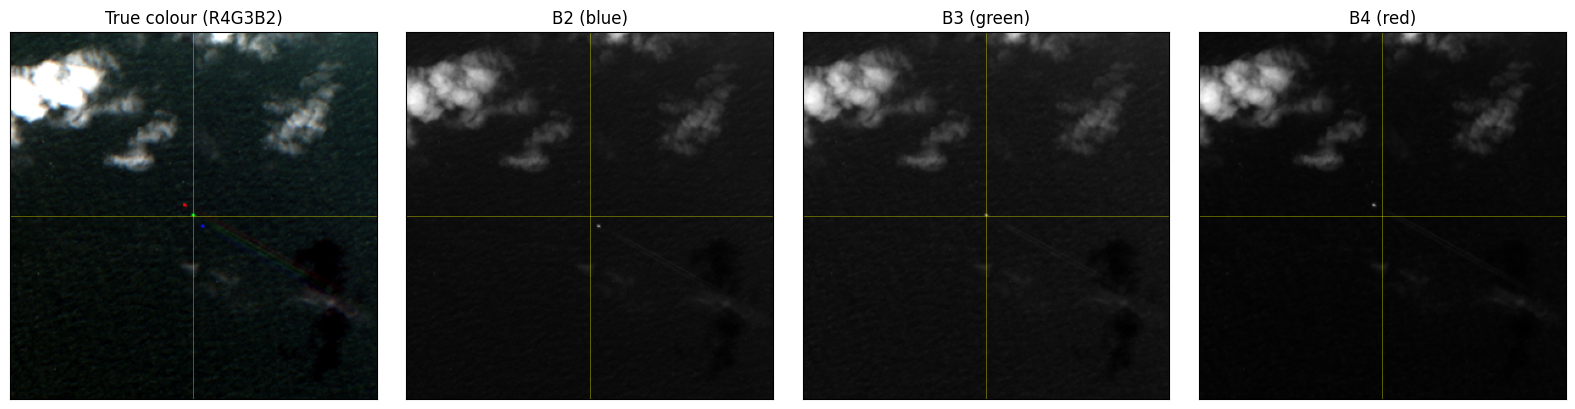

In [60]:
visualise_confirmation.plot_4B_chip(chip)

B2 - B3: max=1926.0 at row=159, col=157
B2 - B4: max=2464.0 at row=159, col=158
B3 - B2: max=1582.0 at row=150, col=150
B3 - B4: max=2484.0 at row=150, col=150
B4 - B2: max=1190.0 at row=142, col=143
B4 - B3: max=1549.0 at row=142, col=143


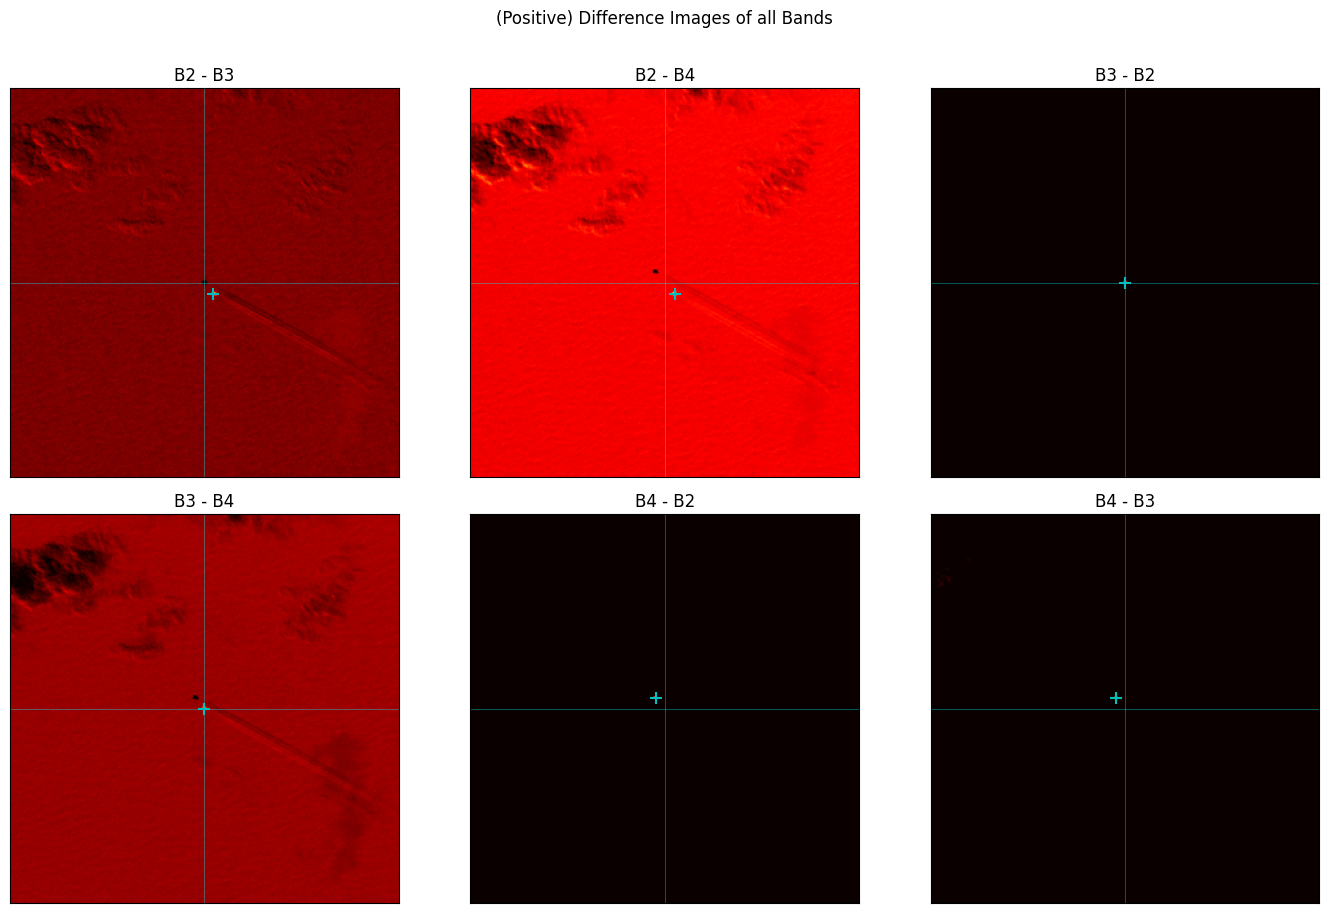

In [61]:
#Inspection of brightest anomalies in difference images
visualise_confirmation.plot_difference_images(chip)

Anomaly pixels:
  B2: 562 px  / 3 components
  B3: 207 px  / 1 components
  B4: 463 px  / 3 components


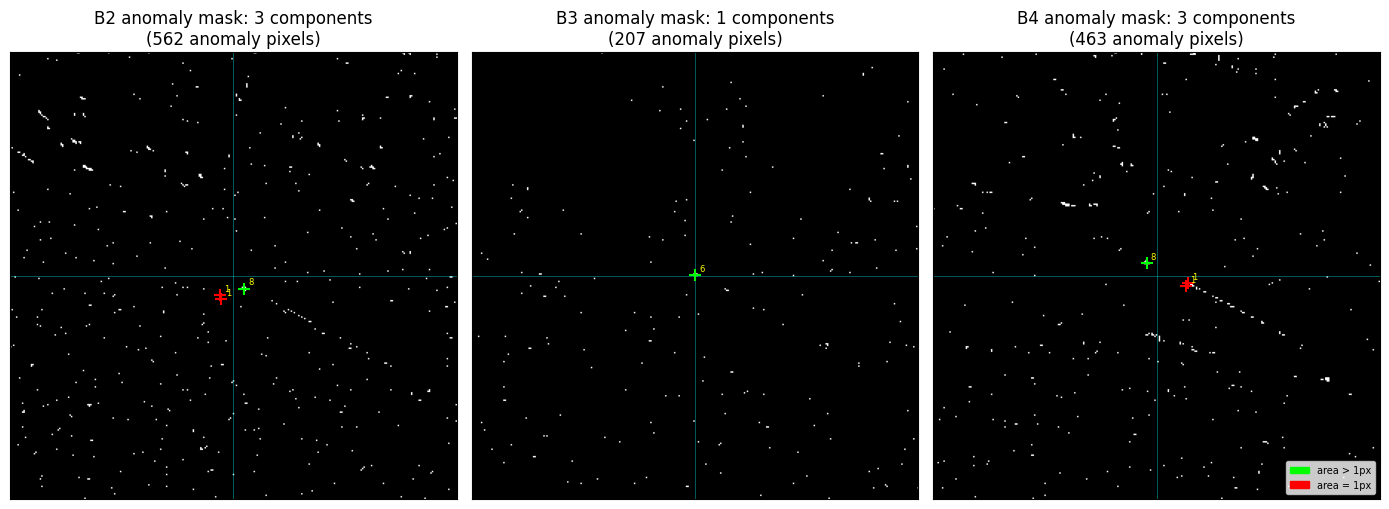

In [62]:
visualise_confirmation.plot_anomaly_masks(chip)

### Step 4b: Collinearity Check

**Input:**
- Reflectance centroids from the `reflectance_centroid` table

**Processing:**
- All possible B2–B3–B4 centroid triplets are formed per chip
- The angle at the B3 vertex is computed for each triplet
- Triplets where the angle at B3 exceeds `COLINEAR_ANGLE_MIN` are flagged as collinear

**Output:**
- One row per tested triplet per chip inserted into the `collinearity_triplet` table

**Inspection (collinearity):**
- `plot_chip_collinearity()`: true colour chip with all tested B2–B3–B4 triplets overlaid (green = passes, red = fails) and per-combination angle scatter
- `passing_angle_scatter()`: histogram of all computed angles across all chips, split by passing and failing combinations

In [50]:
df_collinearity = collinearity_check.run_collinearity_check(run_id, df_reflectance)


Collinearity Check Summary
Total chips          : 584
With colinear combos : 165
No colinear combos   : 419
Total combinations   : 5247
Passing combos       : 220
Non-passing combos   : 5028

Per-tile breakdown:
        chips  colinear
tile                   
T31UEU    584       220


#### Visual Inspection of Collinearity Check

Total combinations      : 5247
Passing (≥170°)         : 220
Failing (<170°)         : 5027


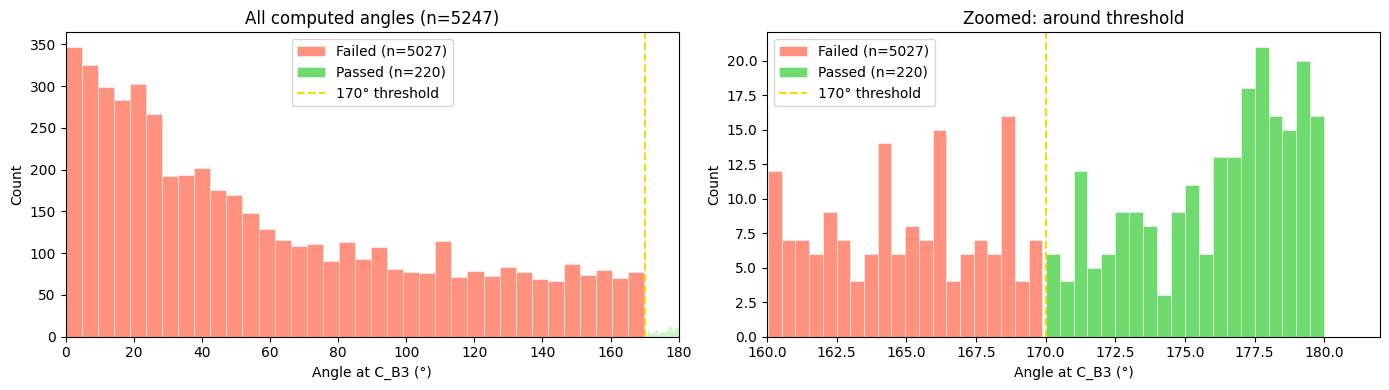

In [63]:
visualise_confirmation.passing_angle_scatter(run_id)


idx=7184  20191003_T31UEU_7184_chip.tif
  Passing combinations : 1
  combo 1: angle=178.9°  B2=(157.5, 158.9)  B3=(150.0, 149.5)  B4=(143.2, 141.4)


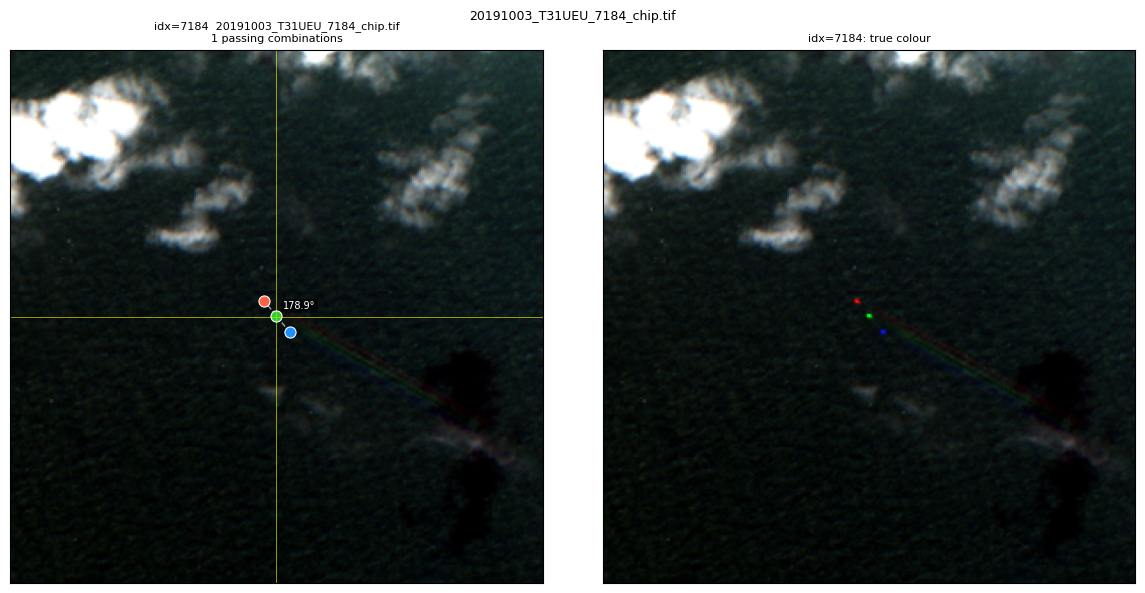

In [64]:
idx = 7184
visualise_confirmation.plot_collinearity(run_id, idx)

### Step 4c: Proportional Displacement Check

**Input:**
- Collinear triplets from the `collinearity_triplet` table

**Processing:**
- For each collinear triplet, inter-band pixel distances are computed: `D_B2_B3` and `D_B3_B4`
- The expected `D_B3_B4` is derived from `D_B2_B3` using the known proportional displacement ratio: `D_B3_B4 = DISPLACEMENT_RATIO × D_B2_B3`
- A candidate is confirmed as a true aircraft if the residual `|D_B3_B4_observed - D_B3_B4_expected|` falls within `DISPLACEMENT_TOLERANCE` metres
- Aircraft speed is estimated from the total B2–B4 displacement and the inter-band time offset

**Output:**
- One row per chip inserted into the `confirmed_detection` table`

**Inspection:**
- `inspect_displacement_calc()`: shows full displacement calculation for a single chip

In [51]:
df_confirmed = displacement_check.run_displacement_check(run_id, df_collinearity)


Displacement Check Summary
Downloaded chips            : 584
Chips with collinear combos : 165
→ Confirmed                 : 65
→ Rejected by displacement  : 100
Confirmed / downloaded chips: 11.1%

Per-tile breakdown:
        candidates  confirmed  rate_pct
tile                                   
T31UEU         584         65      11.1

Speed (confirmed aircraft):
  mean   : 781 km/h
  median : 508 km/h
  min    : 118 km/h
  max    : 4456 km/h


#### Visual Inspection of Displacement Check

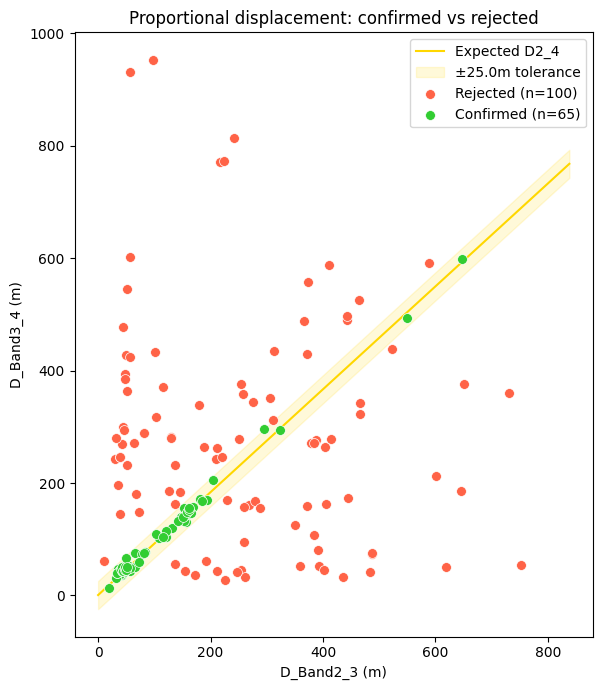

In [65]:
visualise_confirmation.displacement_scatter(run_id)


idx=7184  confirmed=True
  D_Band2_3 : 120.1 m
  D_Band3_4 : 105.6 m
  residual  : 5.0 m
  angle     : 178.9°
  speed     : 808 km/h


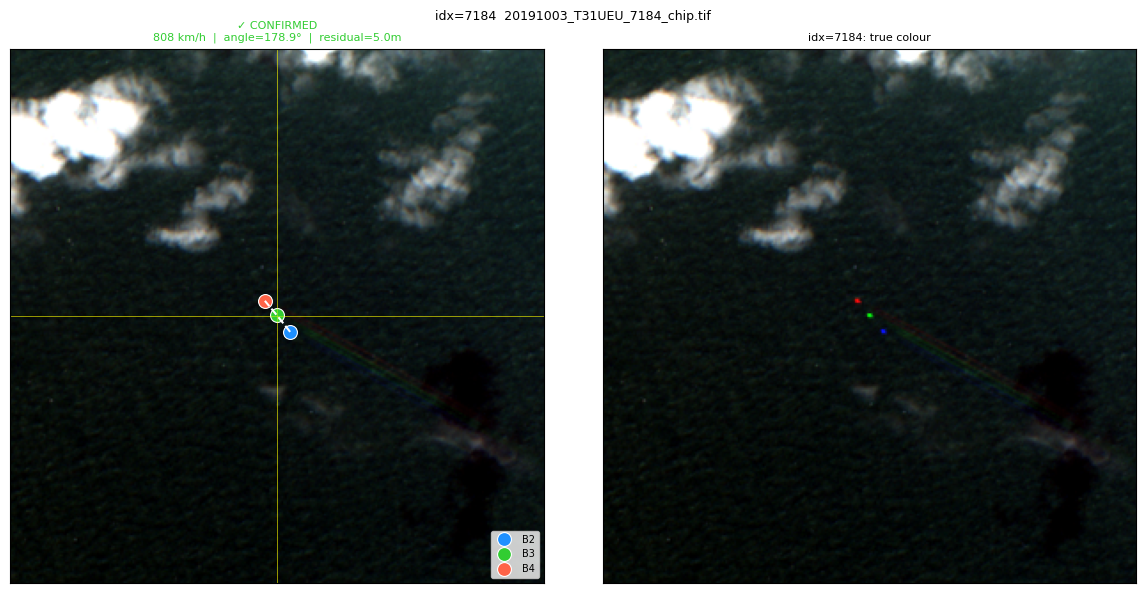

In [66]:
idx = 7184
visualise_confirmation.plot_displacement(run_id, idx)

#### Full Visual Inspection of a Unique Chip
##### Example 1: Confirmed Aircraft

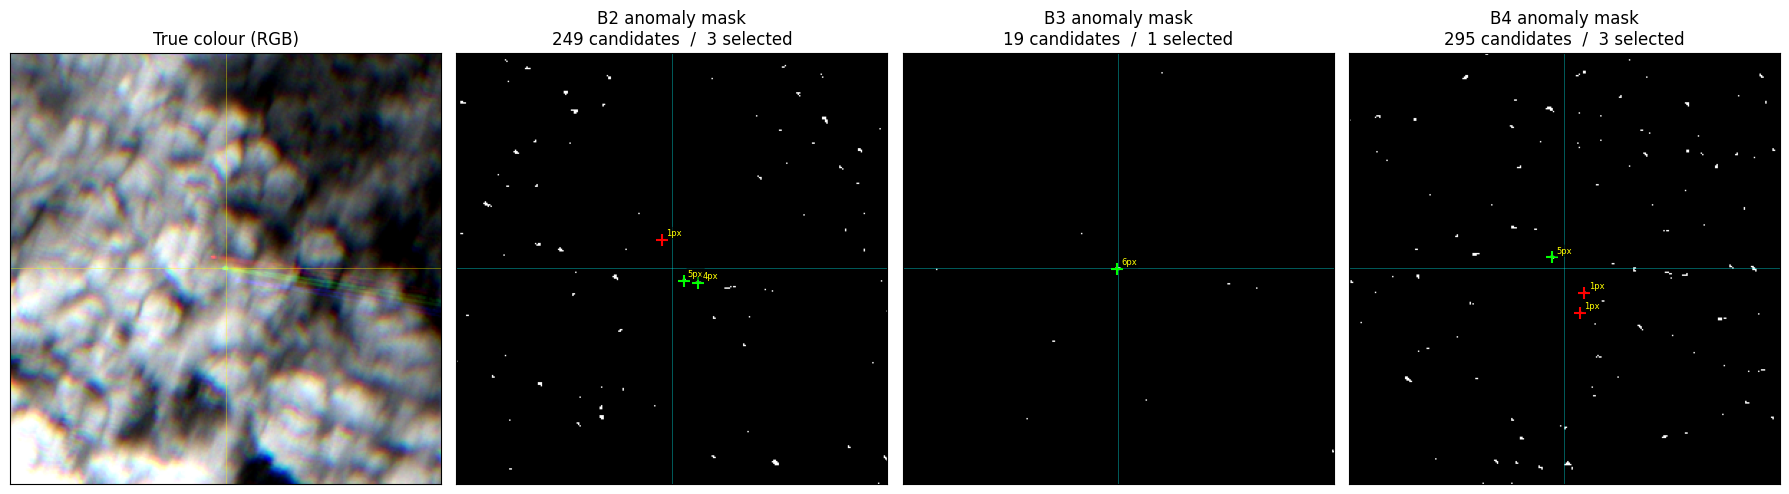

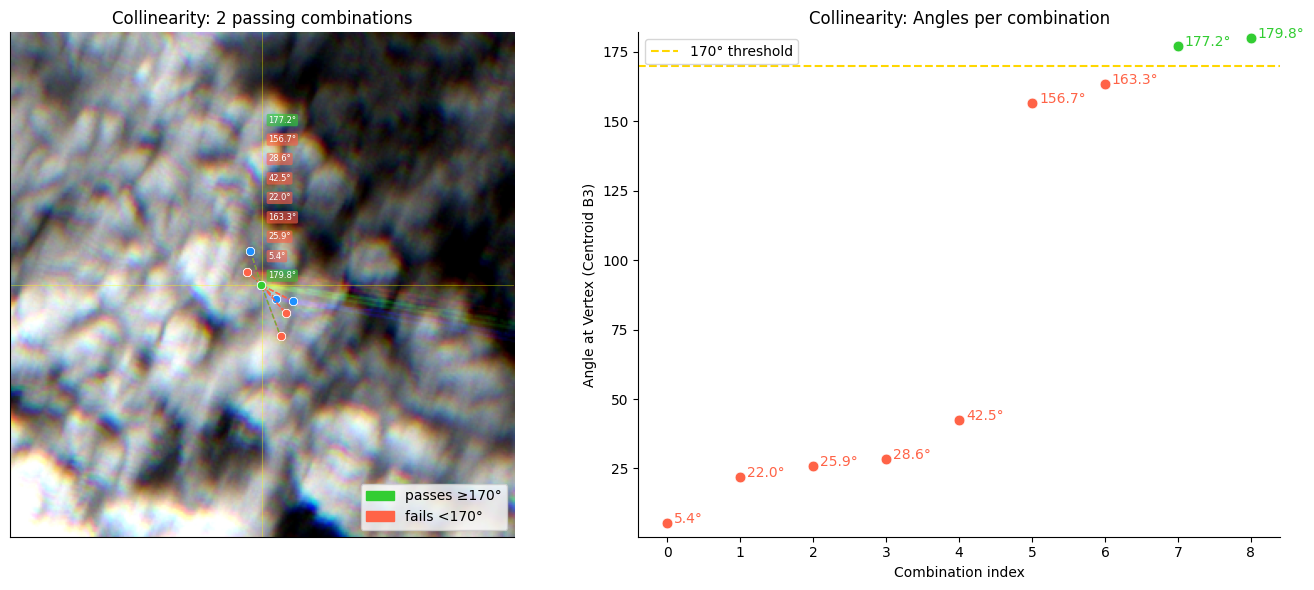

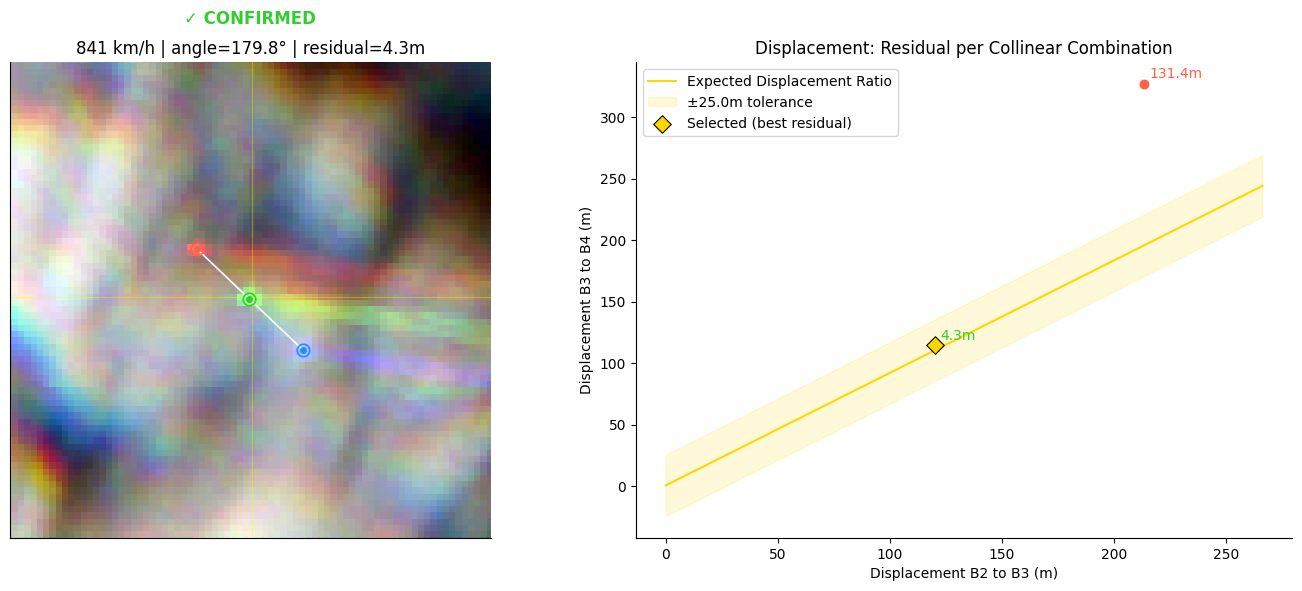

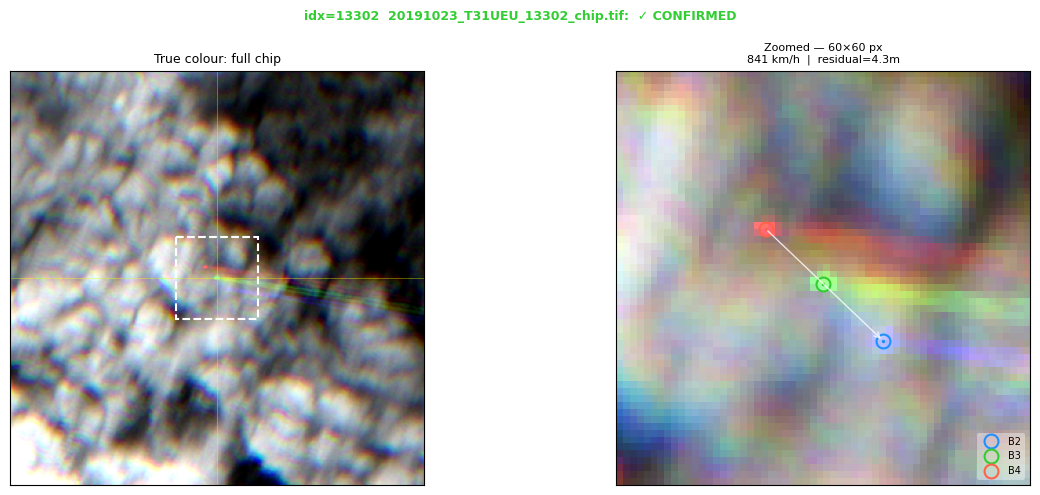

In [ ]:
idx = 13302

visualise_confirmation.plot_chip_reflectance(run_id, idx)
visualise_confirmation.plot_chip_collinearity(run_id, idx)
visualise_confirmation.plot_chip_displacement(run_id, idx)
visualise_confirmation.plot_chip_confirmation(run_id, idx)

##### Example 2: Rejected Detection due to Collinearity Constraint

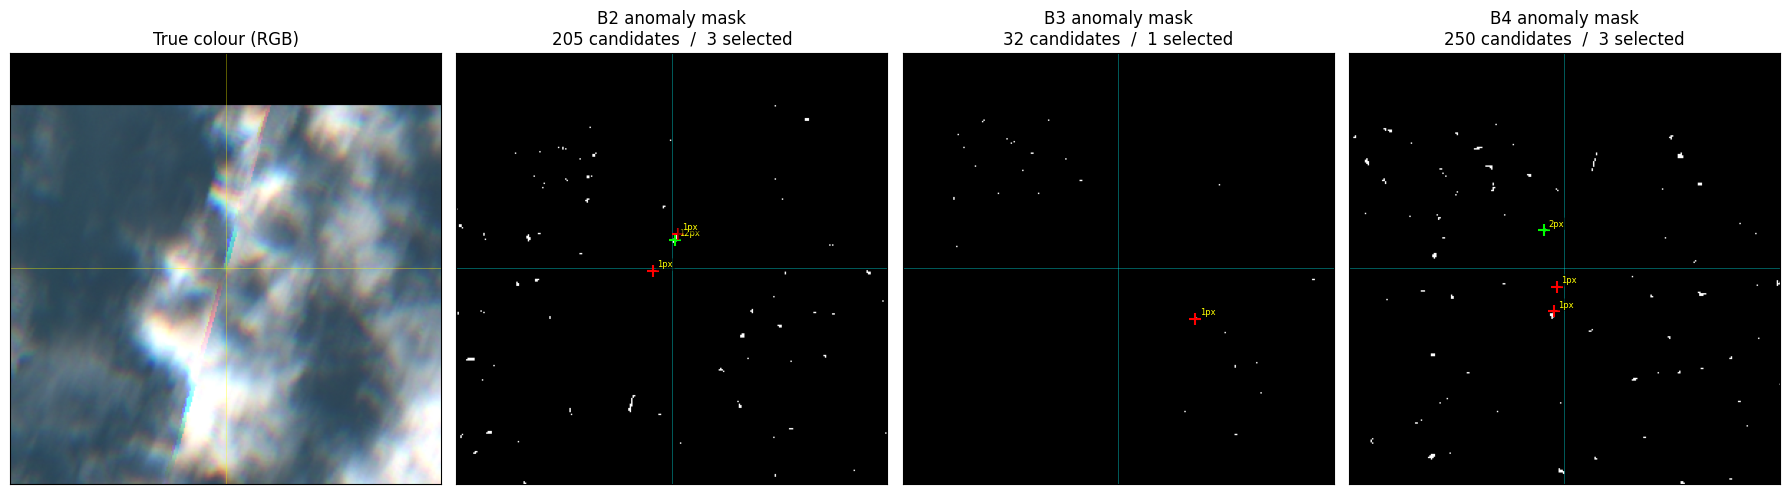

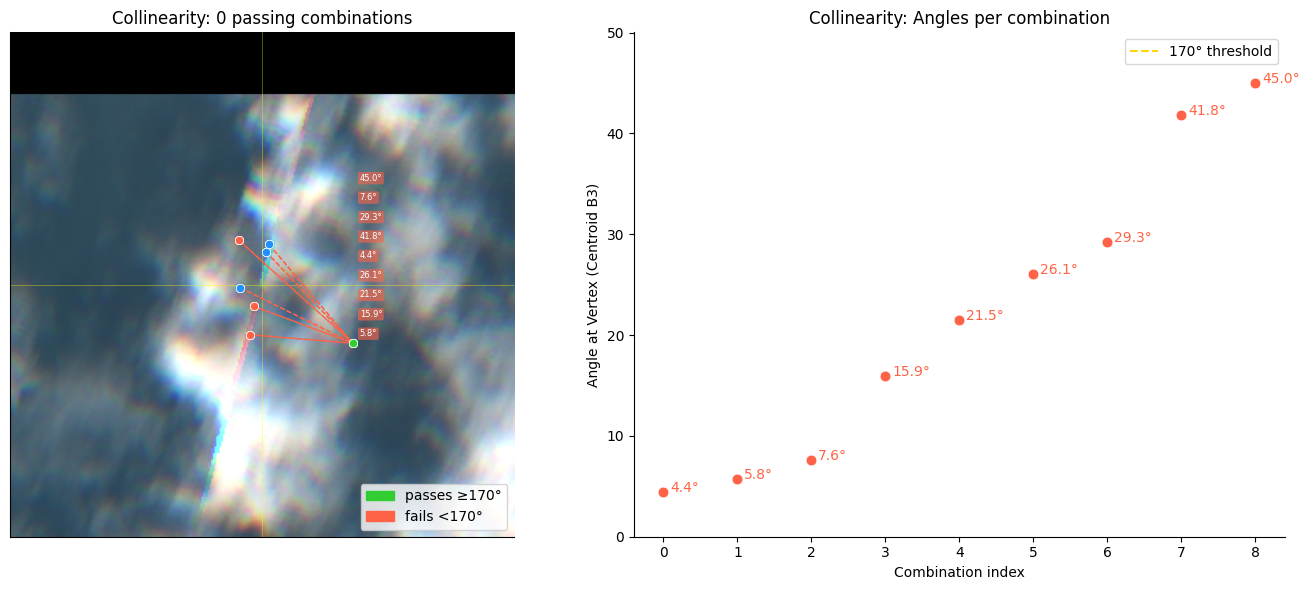

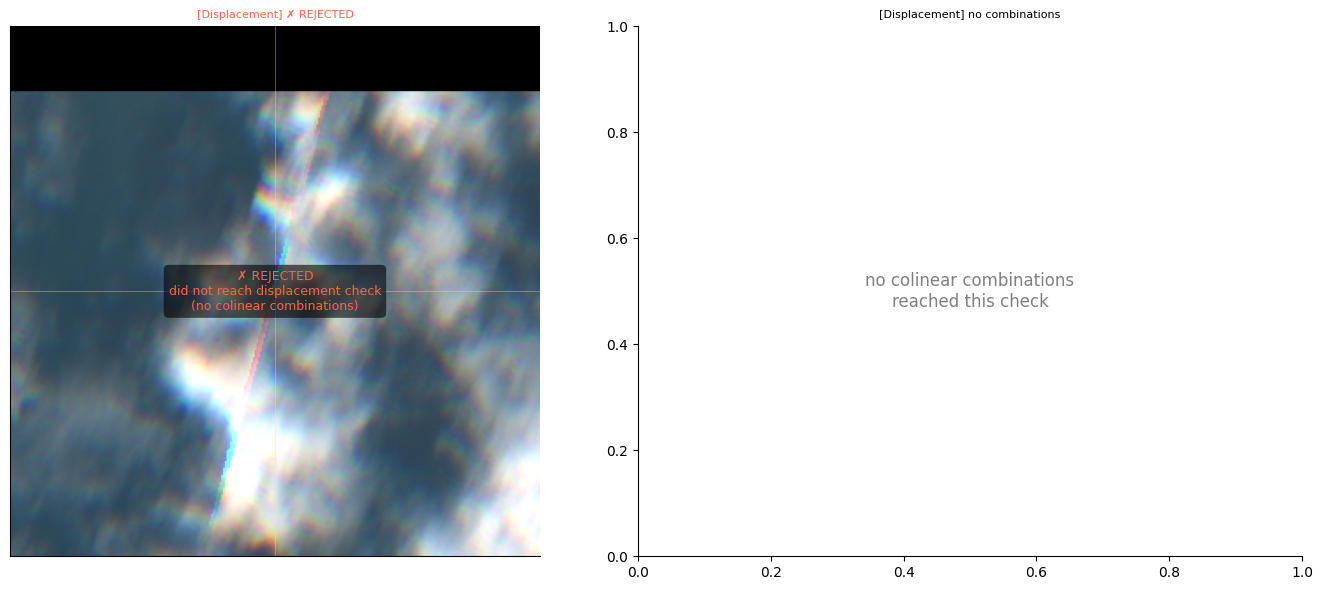

idx=13264 is not a confirmed detection: skipping


In [127]:
idx = 13264

visualise_confirmation.plot_chip_reflectance(run_id, idx)
visualise_confirmation.plot_chip_collinearity(run_id, idx)
visualise_confirmation.plot_chip_displacement(run_id, idx)
visualise_confirmation.plot_chip_confirmation(run_id, idx)

##### Example 3: Rejected Detection due to Displacement Constraint

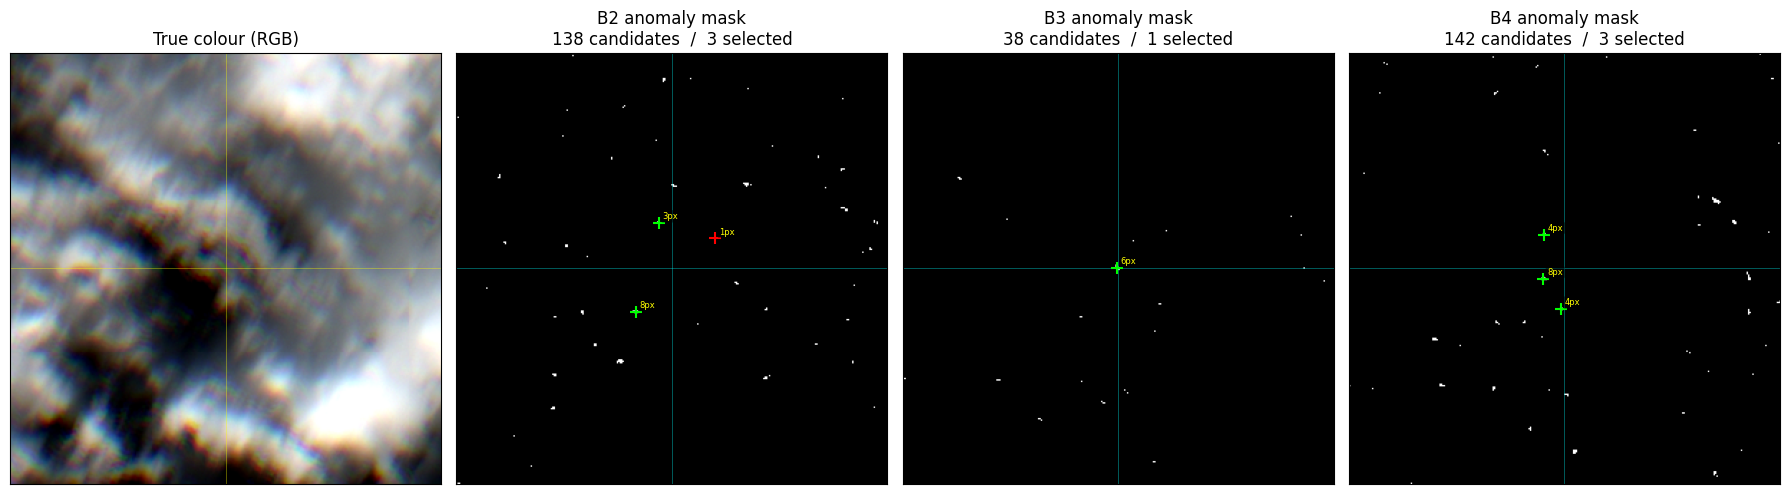

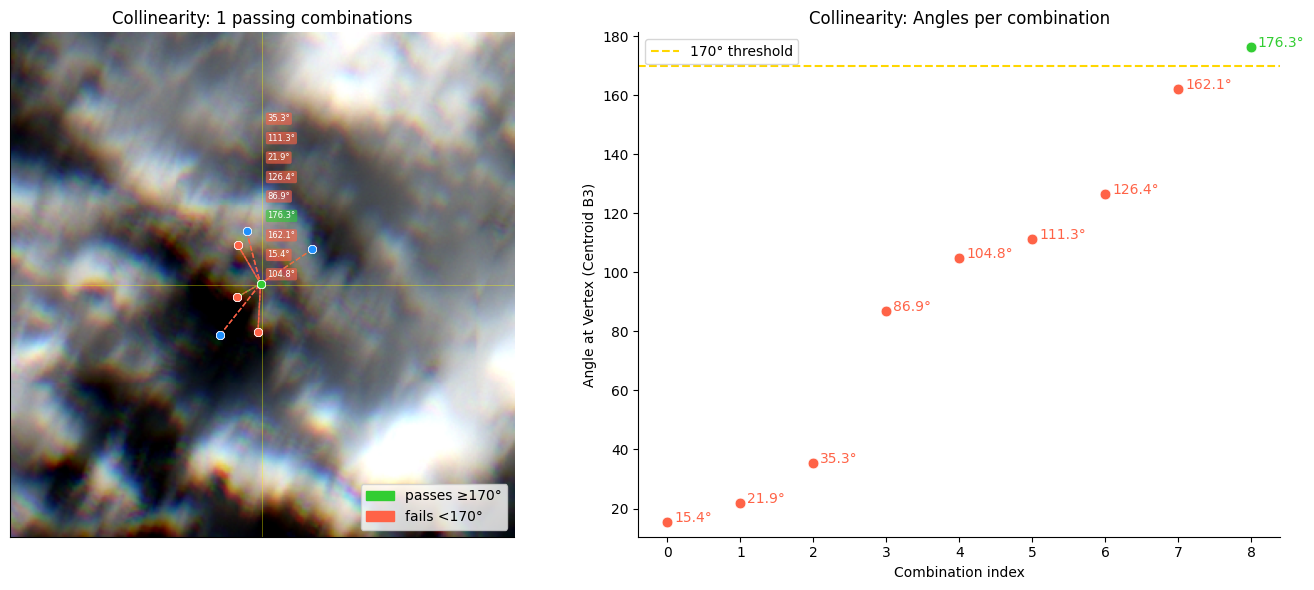

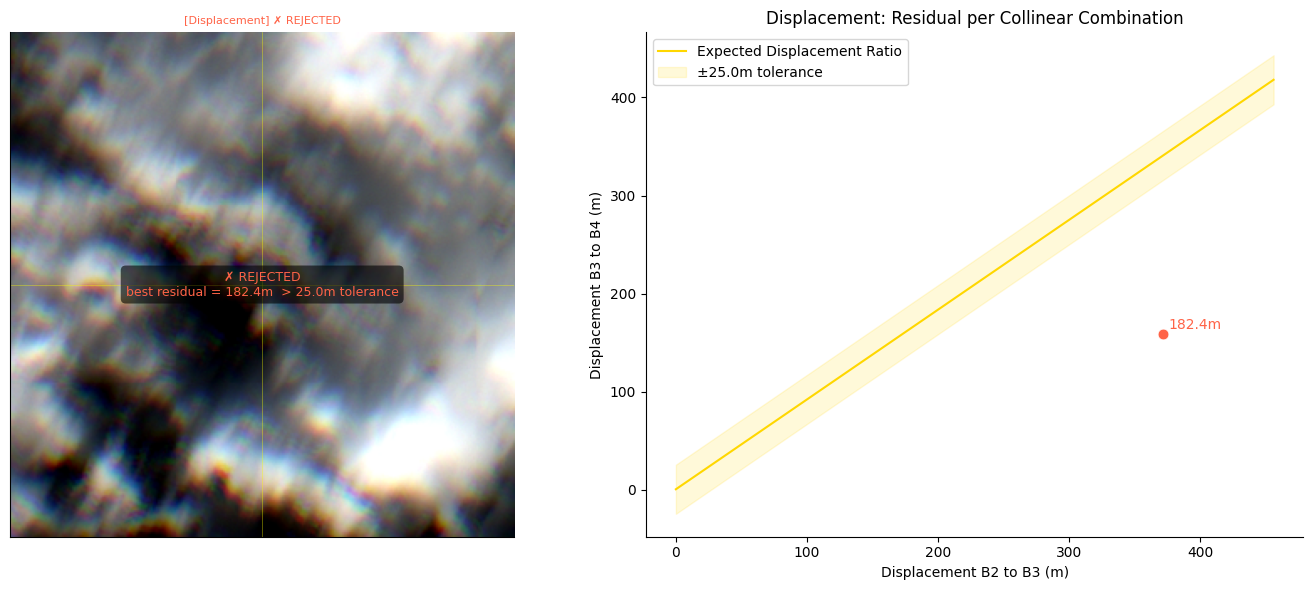

idx=10612 is not a confirmed detection: skipping


In [128]:
idx = 10612

visualise_confirmation.plot_chip_reflectance(run_id, idx)
visualise_confirmation.plot_chip_collinearity(run_id, idx)
visualise_confirmation.plot_chip_displacement(run_id, idx)
visualise_confirmation.plot_chip_confirmation(run_id, idx)

##### Pipeline Summary Visualised


STEP 4 PIPELINE SUMMARY
Candidates entering Step 4 : 584
B3 anomaly found           : 583  (99.8%)
Colinear combination found : 165  (28.3%)
Confirmed aircraft         : 65  (11.1%)

Speed stats:
  mean   : 781 km/h
  median : 508 km/h
  min    : 118 km/h
  max    : 4456 km/h


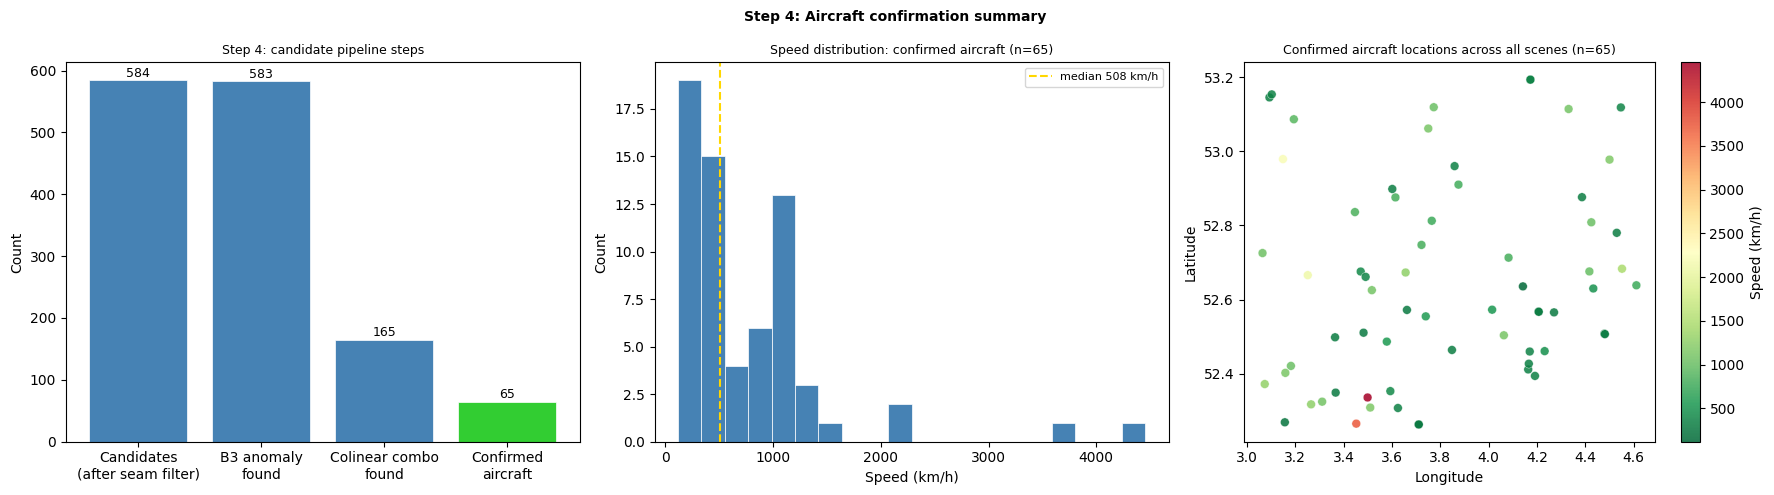

In [77]:
# Full pipeline summary
visualise_confirmation.plot_pipeline_summary(run_id)

## Step 5: ADS-B Cross-Reference

Confirmed detections from the `confirmed_detection` table (joined with `candidate` for lon/lat)

**Input:**
- Confirmed detections from DB
- ADS-B state vectors: queried via OpenSky Trino API or loaded from cache

**Processing:**

- *ADS-B query*: state vectors are queried for each tile's bounding box and time window. Results are cached as Parquet files per scene.

- *ADS-B filtering*: raw state vectors are filtered by time window, spatial bounds, minimum altitude (`ADSB_MIN_ALTITUDE_M`) and minimum velocity (`MIN_VELO_MS`). A unique aircraft is selected closest to row-corrected acquisition time. 

- *Matching*: each confirmed pipeline detection is matched to the nearest ADS-B record within `ADSB_MATCH_THRESHOLD_M`. Detections without a match within the threshold are flagged as unmatched. ADS-B records are flagged as unmatched if no pipeline detection was assigned to them.

**Output:**
- Matched results inserted into the `evaluation_point` table
- Exported GeoJSON file per scene

**Export:**
- Matched results are exported as GeoJSON files per scene: `data/runs/run_id/adsb_annotations/YYYYMMDD_TILE_eval.geojson`
- Each file contains one row per point with annotation fields
- Files are intended for manual visual inspection in a GIS tool (e.g. QGIS). The evaluation of manual inspection results is shown in `03_evaluation.ipynb`

**Requirements:**
- OpenSky Network research account: credentials stored in `.env` as `OPENSKY_USERNAME`
- OAuth2 authentication handled automatically on first connection
- For a demonstration without OpenSky Network credentials, refer to `02_demo.ipynb` which uses cached ADS-B Parquet files. 

In [79]:
results = evaluate.run_evaluation(run_id)
out_paths = export.run_export(run_id, results)


Step 5: ADS-B Evaluation

Total candidates  : 584
Confirmed         : 65
Unique tile/dates : 9

Processing 9 tile/date combinations...


────────────────────────────────────────
Processing T31UEU - 20191001
────────────────────────────────────────
tile_params cache hit:  20191001_31UEU
Open the following URL in browser for the external authentication:
<opensky-oauth-url>
Query returned 701 records in 7.1s
Cached to <repo-root>/data/step5_adsb_cache/20191001_31UEU_adsb_raw.parquet
  Unique aircraft        : 11

Match summary:
  Detections matched to ADS-B : 1 / 3
  ADS-B unmatched             : 10 / 11

────────────────────────────────────────
Processing T31UEU - 20191003
────────────────────────────────────────
Fetching from GEE:      20191003_31UEU
  AOI bbox from mask : 20191003_T31UEU_candidates.tif
Cached to database
Open the following URL in browser for the external authentication:
<opensky-oauth-url>
Query returned 991 records in 5.2s
Cached to <repo-root>/data/step5_adsb_cache/

## Alternative: One-Shot End-to-End Execution

- All sections above executed steps 1-5 one stage at a time so each intermediate result could be inspected. 
- If a one-shot end-to-end pipeline run:

In [ ]:
#Defining input parameters
start_date = '2019-10-01' #Format: 'YYYY-MM-DD'
end_date = '2019-10-31' 
tile_name = '31UEU'

#define AOI via GEE call
image = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filter(ee.Filter.eq('MGRS_TILE', f'{tile_name}'))
    .first())

# Get tile geometry
aoi = image.geometry()
aoi_selection.aoi_summary(aoi)
aoi = aoi

In [ ]:
pipeline = Pipeline()
run_id = pipeline.start_run(aoi, start_date, end_date, tile_name=tile_name)
print(f"run_id = {run_id}")
df_confirmed = pipeline.run(run_id)  # from_step="step1", to_step="step4" by default

In [ ]:
#add ADS-B cross-referencing
pipeline.run(run_id, from_step="step5", to_step="step5") 

In [ ]:
#resumes a partially-completed run instead
pipeline.run(run_id, from_step="step3", to_step="step4") 